# Deep Leakage from Gradients attack in CNN

This notebook contains the code for the attack Deep Leakage from gradients (DLG) and imporved-DLG (iDLG) on LeNet model (CNN).

In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, Subset
import matplotlib.pyplot as plt
import copy
import math
from scipy.stats import norm
from opacus import PrivacyEngine

### Utility functions

* `show_reconstruciton` saves reconstructions as images.
* `moving_avg` computes the [simple moving average](https://en.wikipedia.org/wiki/Moving_average) of a vector.
* `load_mnist_lenet` laods and returns the dataloader of MNIST dataset configured ready to feed into LeNet model.
* `total_variation_loss` Computes Total Variation loss for a flattened image tensor.

In [2]:
def show_reconstructions(rec_x_per_epoch,
                         save_path,
                         cmap="gray"):
    """
    rec_x_per_epoch:
        list of length num_epochs
        each element is a list of length batch_size
        each entry is a flattened (1024,) image

    Output layout:
        rows    = batch elements
        columns = epochs
    """

    num_epochs = len(rec_x_per_epoch)
    batch_size = len(rec_x_per_epoch[0])

    fig, axes = plt.subplots(
        batch_size,
        num_epochs,
        figsize=(num_epochs * 1.5, batch_size * 1.5),
        squeeze=False
    )

    for e in range(num_epochs):
        for b in range(batch_size):

            x_rec = rec_x_per_epoch[e][b]

            # handle torch tensors
            if hasattr(x_rec, "detach"):
                x_rec = x_rec.detach().cpu().numpy()

            x_rec = np.squeeze(x_rec)
            img = x_rec.reshape(32, 32)

            ax = axes[b, e]
            ax.imshow(img, cmap=cmap)

            ax.set_xticks([])
            ax.set_yticks([])

            # thin red border
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(0.5)

            # epoch label on top row
            if b == 0:
                ax.set_title(f"Ep. {e+1}", fontsize=28, pad=2)

    # remove all spacing
    plt.subplots_adjust(
        left=0,
        right=1,
        top=1,
        bottom=0,
        wspace=0.03,
        hspace=0
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

def moving_avg(x, window=10):
    x = np.array(x)
    return np.convolve(x, np.ones(window)/window, mode="valid")

def load_mnist_lenet(batch_size=64, n_train=None, n_test=None, data_dir='./data/mnist'):
    """
    Loads MNIST resized to 32x32 and returns PyTorch DataLoaders
    ready for LeNet.

    Args:
        batch_size: batch size for training
        n_train: optional subset size for training
        n_test: optional subset size for test
        data_dir: str the directory of the mnist dataset.

    Returns:
        train_loader, test_loader
    """

    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),   # -> (1, 32, 32)
    ])

    train_set = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

    test_set = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

    # Optional subsampling
    if n_train is not None:
        idx = torch.randperm(len(train_set))[:n_train]
        train_set = Subset(train_set, idx)

    if n_test is not None:
        idx = torch.randperm(len(test_set))[:n_test]
        test_set = Subset(test_set, idx)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader


def total_variation_loss(x, height=32, width=32):
    """
    Batched Total Variation Loss.

    Args:
        x: torch.Tensor of shape
            (B, H*W)      or
            (B, 1, H, W)

    Returns:
        scalar tensor = mean TV across batch
    """

    # if flattened → reshape
    if x.dim() == 2:
        B = x.size(0)
        img = x.view(B, 1, height, width)

    # already image-shaped
    elif x.dim() == 4:
        img = x

    else:
        raise ValueError("x must be (B,H*W) or (B,1,H,W)")

    # horizontal & vertical diffs
    diff_h = img[:, :, :, 1:] - img[:, :, :, :-1]
    diff_v = img[:, :, 1:, :] - img[:, :, :-1, :]

    # TV per image
    tv_per_img = (
        diff_h.pow(2).sum(dim=(1,2,3)) +
        diff_v.pow(2).sum(dim=(1,2,3))
    )

    # mean over batch
    return tv_per_img.mean()


### Define Model

Next we define the [LeNet](https://en.wikipedia.org/wiki/LeNet) model as well as some useful functions:

* `grad_norm` calculates and returns the norm of a model.
* `weights_init` initializes the weights of a model at random 

In [10]:
def grad_norm(model, norm_type=2):
    """
    Computes the norm of gradients of all parameters in a model.

    Args:
        model (nn.Module): PyTorch model with computed gradients
        norm_type (float): type of norm (2 for L2, 1 for L1, float('inf') for max)

    Returns:
        float: gradient norm
    """
    total_norm = 0.0
    num_elems = 0

    if norm_type == float('inf'):
        total_norm = max(
            p.grad.abs().max().item()
            for p in model.parameters()
            if p.grad is not None
        )
        return total_norm

    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(norm_type)
            total_norm += param_norm.item() ** norm_type
            num_elems += p.grad.numel()

    total_norm = total_norm ** (1.0 / norm_type)
    return total_norm, num_elems



def weights_init(m):
    if hasattr(m, "weight"):
        m.weight.data.uniform_(-0.5, 0.5)
    if hasattr(m, "bias"):
        m.bias.data.uniform_(-0.5, 0.5)

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        act = nn.Sigmoid
        self.body = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
        )
        self.fc = nn.Sequential(
            nn.Linear(768, 10)
        )

    def forward(self, x):
        x = self.body(x)
        x = torch.flatten(x, 1)
        # print(out.size())
        x = self.fc(x)
        return x

### Vanilla train of the model

Train the model without any additive noise for later comparisons.

In [4]:
def train(model, train_loader, test_loader, epochs, optimizer, loss_function):
    loss_per_epoch = []
    test_acc_per_epoch = []
    train_acc_per_epoch = []
    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        correct, total = 0, 0
        for i, data in enumerate(train_loader, 0):
            x_batch, y_batch = data
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            optimizer.step()
            tot_loss += loss.item()

            outputs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        loss_per_epoch.append(tot_loss)
        train_acc_per_epoch.append(correct/total)
    
        # Evaluate after each epoch
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                outputs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
            acc = correct / total
            test_acc_per_epoch.append(acc)
    
        print(f"Epoch {epoch+1}: Test acc: {test_acc_per_epoch[epoch]:.4f}, train acc: {train_acc_per_epoch[epoch]:.4f}, epoch loss: {loss_per_epoch[epoch]:.4f}")
    
    return test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, tot_loss
            

In [6]:
train_loader, test_loader = load_mnist_lenet(batch_size=1, n_train=4000, n_test=1000, data_dir='../data/mnist')
model = LeNet()
model.apply(weights_init)
loss_function = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, cummulative_loss = train(model, train_loader, test_loader, epochs, optimizer, loss_function)


Epoch 1: Test acc: 0.8650, train acc: 0.6388, epoch loss: 4508.4651
Epoch 2: Test acc: 0.9010, train acc: 0.8768, epoch loss: 1545.2701
Epoch 3: Test acc: 0.8840, train acc: 0.9130, epoch loss: 1087.7981
Epoch 4: Test acc: 0.9320, train acc: 0.9377, epoch loss: 775.7284
Epoch 5: Test acc: 0.9260, train acc: 0.9477, epoch loss: 631.9614
Epoch 6: Test acc: 0.9370, train acc: 0.9567, epoch loss: 506.6553
Epoch 7: Test acc: 0.9480, train acc: 0.9688, epoch loss: 416.8793
Epoch 8: Test acc: 0.9330, train acc: 0.9688, epoch loss: 360.8265
Epoch 9: Test acc: 0.9550, train acc: 0.9780, epoch loss: 258.5427
Epoch 10: Test acc: 0.9490, train acc: 0.9835, epoch loss: 209.0625


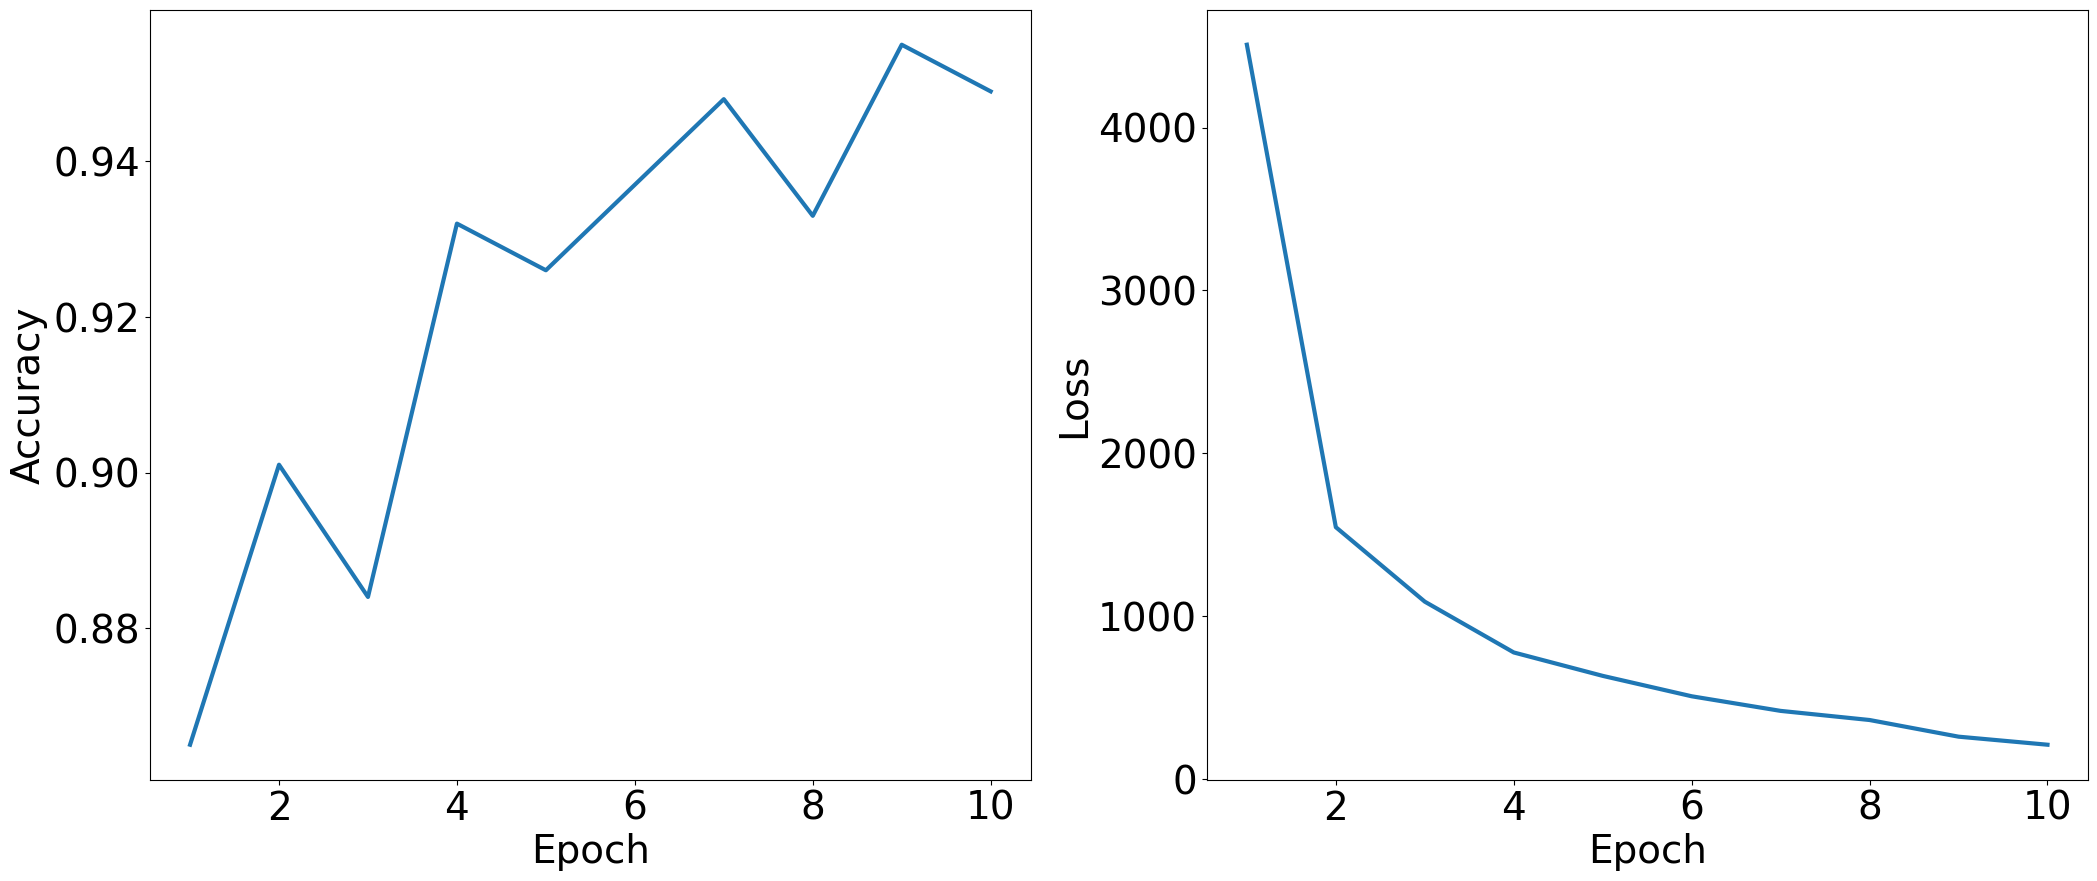

In [7]:
plt.figure(figsize=(25, 10))
plt.rcParams.update({'font.size': 28})
plt.subplot(1,2,1)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(range(1, epochs+1), test_acc_per_epoch , linestyle='-', linewidth=3, label='noisless')

plt.subplot(1,2,2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(range(1, epochs+1), loss_per_epoch , linestyle='-', linewidth=3, label='noisless')

plt.show()

## Train with noise

In [5]:
def get_grad_vector(grad):
    """
    Returns all gradients of model parameters as a single flattened vector.
    Assumes backward() has already been called.
    """
    grad_list = []

    for param in grad:
        if param.grad is not None:
            grad_list.append(param.grad.view(-1))
        else:
            # If a parameter has no gradient, append zeros of same size
            grad_list.append(torch.zeros_like(param).view(-1))

    return torch.cat(grad_list)

In [6]:
def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(- target * F.log_softmax(pred, dim=-1), 1))

def add_noise_to_grads(model, epsilon, sensetivity, q, delta=1e-5):
    '''
    Add noise to the gradients of the model via the subsampled one shot gaussian mechanism.
    '''
    # Compute gradient norm and size
    grad_sq_sum = 0.0
    num_elems = 0
    grad_tuple = []

    for p in model.parameters():
        if p.grad is not None:
    
            if not torch.isfinite(p.grad).all():
                p.grad.data = torch.nan_to_num(
                    p.grad.data,
                    nan=0.0,
                    posinf=1e4,
                    neginf=-1e4
                )
    
    if epsilon != None:
        delta_2 = 2*sensetivity
        alpha_star = find_alpha_star(epsilon, delta, q)
        sigma = delta_2/(math.sqrt(2*alpha_star))
        if math.isnan(sigma):
            sigma = 1e12
    else:
        sigma = 1e12 # infinity (Very very large)

    # Add Gaussian noise to each gradient
    for p in model.parameters():
        if p.grad is not None:
            noise = torch.randn_like(p.grad) * sigma
            if epsilon != None:
                p.grad.add_(noise)
            
            grad_tuple.append(p.grad)
            
    grad = tuple(g.detach().clone() for g in grad_tuple)
    #grad_tuple = tuple(grad_tuple)
    return sigma, grad_tuple

    
def dlg_attack(original_dy_dx, model, criterion=cross_entropy_for_onehot, loss_function="grad_diff", batch_size=1):
    '''
    iDLG attack.
    original_dy_dx: the gradient of the model's training shared to the clients.
    model: the model to be attacked
    criterion: the loss funtion used by the model
    loss_funtion: the loss funtion used by th attack. 'grad_diif' is the original, 'cosine similarity' for the cosine similarity loss funtion.
    '''
    # generate dummy data and label
    dummy_data = torch.randn((batch_size,1, 32, 32)).requires_grad_(True)
    dummy_label = torch.randn((batch_size,10), requires_grad=True)
    optimizer = torch.optim.Adam([dummy_data, dummy_label], lr=0.1)
    #optimizer = torch.optim.LBFGS([dummy_data,], lr=1)
    #criterion_iDLG = nn.CrossEntropyLoss()

    history = []
    convergance = 1e10
    prev_loss = 1e10
    current_loss = 1e10
    iters = 0
    while (iters < 3000 and current_loss>1e-3):
        if iters != 0:
            prev_loss = current_loss
        def closure():
            optimizer.zero_grad()
    
            pred = model(dummy_data)
            dummy_onehot_label = F.softmax(dummy_label, dim=-1)
            #last_bias_grad = original_dy_dx[-1]   
            #label_pred = torch.argmin(last_bias_grad).view(1)
            #dummy_loss = criterion_iDLG(pred, label_pred)
            dummy_loss = criterion(pred, dummy_onehot_label) 
            dummy_dy_dx = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)

            grad_diff = 0
            grad_count = 0
            if loss_function=='cosine similarity':
                lambda_tv = 1e-6
                grad_diff = 0
                total = 0
                
                for gx, gy in zip(dummy_dy_dx, original_dy_dx):
                    cos = F.cosine_similarity(gx.reshape(1, -1), gy.reshape(1, -1), eps=1e-8)
                    
                    n = gy.numel()
                    grad_diff += n * (1 - cos)
                    total += n
                
                grad_diff = grad_diff / total
                tv_loss = total_variation_loss(dummy_data,  height=28, width=28)
                grad_diff = grad_diff + lambda_tv * tv_loss

            elif loss_function == 'nDLG':
                for gx, gy in zip(dummy_dy_dx, original_dy_dx): 
                    gx_norm = torch.norm(gx, p=2)
                    gy_norm = torch.norm(gy, p=2)
    
                    gx_normalized = gx / (gx_norm + 1e-12)
                    gy_normalized = gy / (gy_norm + 1e-12)
    
                    grad_diff += ((gx_normalized - gy_normalized) ** 2).sum()
                    #grad_diff += ((gx - gy) ** 2).sum()
            else:
                for gx, gy in zip(dummy_dy_dx, original_dy_dx): 
                    grad_diff += ((gx - gy) ** 2).sum()

            grad_diff.backward()
    
            return grad_diff
    
        current_loss = optimizer.step(closure)
        dummy_data.data.clamp_(0,1)
        dummy_label.data.clamp_(-10,10)
        current_loss = current_loss.item()
        convergance = np.abs(current_loss - prev_loss)/np.abs(current_loss)
        history.append(dummy_data.cpu())
        iters += 1
       
    print(f'Iters: {iters}, Loss: {current_loss:.4f}, Convergance value: {convergance:.6f}')
    return history

def noisy_train(model, train_loader, test_loader, epochs, optimizer, loss_function,
                 epsilon, attack='grad_diff', batch_size=1, max_grad_norm=1):
    loss_per_epoch = []
    test_acc_per_epoch = []
    train_acc_per_epoch = []
    rec_x_per_epoch = []
    rec_error_per_epoch = []
    grad_norm_per_epoch = []
    avg_snr_per_epoch = []
    
    
    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        correct, total = 0, 0
        rec_error, sigma, emp_snr_avg = 0.0, 0.0, 0.0

        rec_error_per_epoch.append([])
        grad_norm_per_epoch.append([])
        for i, data in enumerate(train_loader, 0):
            x_batch, y_batch = data
            optimizer.zero_grad()

            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            norm_before = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
            norm_after, N = grad_norm(model)
            sigma, grad = add_noise_to_grads(model, epsilon, max_grad_norm, B/len(train_loader)) # Here we calculate std based on snr and add noise to gradients.
            snr1 = norm_after**2/(N*sigma**2)
            snr2 = find_alpha_star(epsilon, 1e-5, batch_size/5000)/N
            emp_snr_avg += snr1
            #print(f'N: {N}, simga: {sigma:.5f}, signal norm: {norm_after}, \nSNR empirical: {snr1}\nSNR theoretical: {snr2}')
            
            # Perform attack. 
            if (i == 0): 
                # Share the gradients with clients.
                # Make a deep copy of the model so we avoid conflicts with backpropagation.
                frozen_model = copy.deepcopy(model).eval()

                # Try the attack many times to avoid bad reconstructions due to bad initialization of data.
                for trial in range(3):    
                    rec_x = []
                    history = dlg_attack(grad, frozen_model, loss_function=attack, batch_size=batch_size)

                    rec_x_batched = history[-1].detach()
                    rec_error = 0.0
                    for b in range(batch_size):
                        rec_x.append(rec_x_batched[b].flatten())
                        x = x_batch[b].detach().flatten()
                        rec_error += F.cosine_similarity(rec_x[b], x, dim=0)
                    rec_error = rec_error.item()/batch_size # Take the average loss of all batch
                    if rec_error > 0.6:
                        break 
                
                if i == 0:
                    rec_x_per_epoch.append(rec_x)
                rec_error_per_epoch[epoch].append(rec_error)
                grad_norm_per_epoch[epoch].append(grad_norm(model))
                print(f'Iter: {i+1}, rec_error: ', rec_error, f',grad L2 norm: {grad_norm_per_epoch[epoch][-1]}, Sigma: {sigma}')
            
            optimizer.step()
    

            tot_loss += loss.item()

            outputs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        

        loss_per_epoch.append(tot_loss)
        train_acc_per_epoch.append(correct / total)
        avg_snr_per_epoch.append(emp_snr_avg * (B/len(train_loader)))

        # Evaluation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                outputs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        acc = correct / total
        test_acc_per_epoch.append(acc)
        
        print(f"Epoch {epoch+1}: Test acc: {acc:.4f}, train acc: {train_acc_per_epoch[epoch]:.4f}, epoch loss: {loss_per_epoch[epoch]:.4f}, reconstruction error: {rec_error:.4f}, sigma: {sigma:.4f}, grad_norm berfor:{norm_before:.4f} grad_norm: {norm_after:.4f}")
        print(f"Empirical SNR: {avg_snr_per_epoch[-1]}, alpha: {snr2}")
    #show_reconstructions(rec_x_per_epoch, epochs, batch_size, f"./grid_{attack}_eps{epsilon}.png")
    error_grads = (rec_error_per_epoch, grad_norm_per_epoch)
    return test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, tot_loss, rec_x_per_epoch, error_grads, avg_snr_per_epoch

In [12]:
B=1
train_loader, test_loader = load_mnist_lenet(batch_size=B, n_train=4000, n_test=1000, data_dir='../data/mnist')
model = LeNet()
model.apply(weights_init)
loss_function = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
snr = None
epochs = 40
epsilon = 10
max_grad_norm = 1



noisy_test_acc_per_epoch, noisy_train_acc_per_epoch, noisy_loss_per_epoch, noisy_cummulative_loss, noisy_rec_x_per_epoch, error_grads, avg_snr_per_epoch = noisy_train(model, train_loader, test_loader, 
                                                                                                                                           epochs, optimizer, loss_function, epsilon, attack='cosine similarity', batch_size=B,
                                                                                                                                                   max_grad_norm=max_grad_norm)
errors = np.array(error_grads[0])
grads = np.array(error_grads[1])

Iters: 3000, Loss: 0.8872, Convergance value: 0.000078
Iters: 3000, Loss: 0.8876, Convergance value: 0.000080
Iters: 3000, Loss: 0.8876, Convergance value: 0.000086
Iter: 1, rec_error:  0.2874853014945984 ,grad L2 norm: (59.01927090530335, 18838), Sigma: 0.42745011434460883
Epoch 1: Test acc: 0.1160, train acc: 0.1113, epoch loss: 10064.8651, reconstruction error: 0.2875, sigma: 0.4275, grad_norm berfor:23.2769 grad_norm: 1.0000
Empirical SNR: 0.00029053218886845915, alpha: 0.0006097667039743327
Iters: 3000, Loss: 0.8869, Convergance value: 0.000054
Iters: 3000, Loss: 0.8858, Convergance value: 0.000109
Iters: 3000, Loss: 0.8876, Convergance value: 0.000196
Iter: 1, rec_error:  0.3081050217151642 ,grad L2 norm: (58.93465733517502, 18838), Sigma: 0.42745011434460883
Epoch 2: Test acc: 0.1450, train acc: 0.1520, epoch loss: 9097.9713, reconstruction error: 0.3081, sigma: 0.4275, grad_norm berfor:21.8399 grad_norm: 1.0000
Empirical SNR: 0.00029053218663404435, alpha: 0.0006097667039743327

<>:28: SyntaxWarning: invalid escape sequence '\h'
<>:28: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_72180/2766778596.py:28: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel(r'cos($\hat{x}$, x)')


"\nplt.plot(avg_snr_per_epoch, linewidth=3)\nplt.xlabel('Epoch')\nplt.ylabel(r'Empirical SNR')\nplt.title('Empirical SNR per epoch')\nplt.grid(True, alpha=0.7)\nplt.savefig('./subOSGM_emp_snr_per_epoch_eps10_delta1e-5_CNN.png')\n"

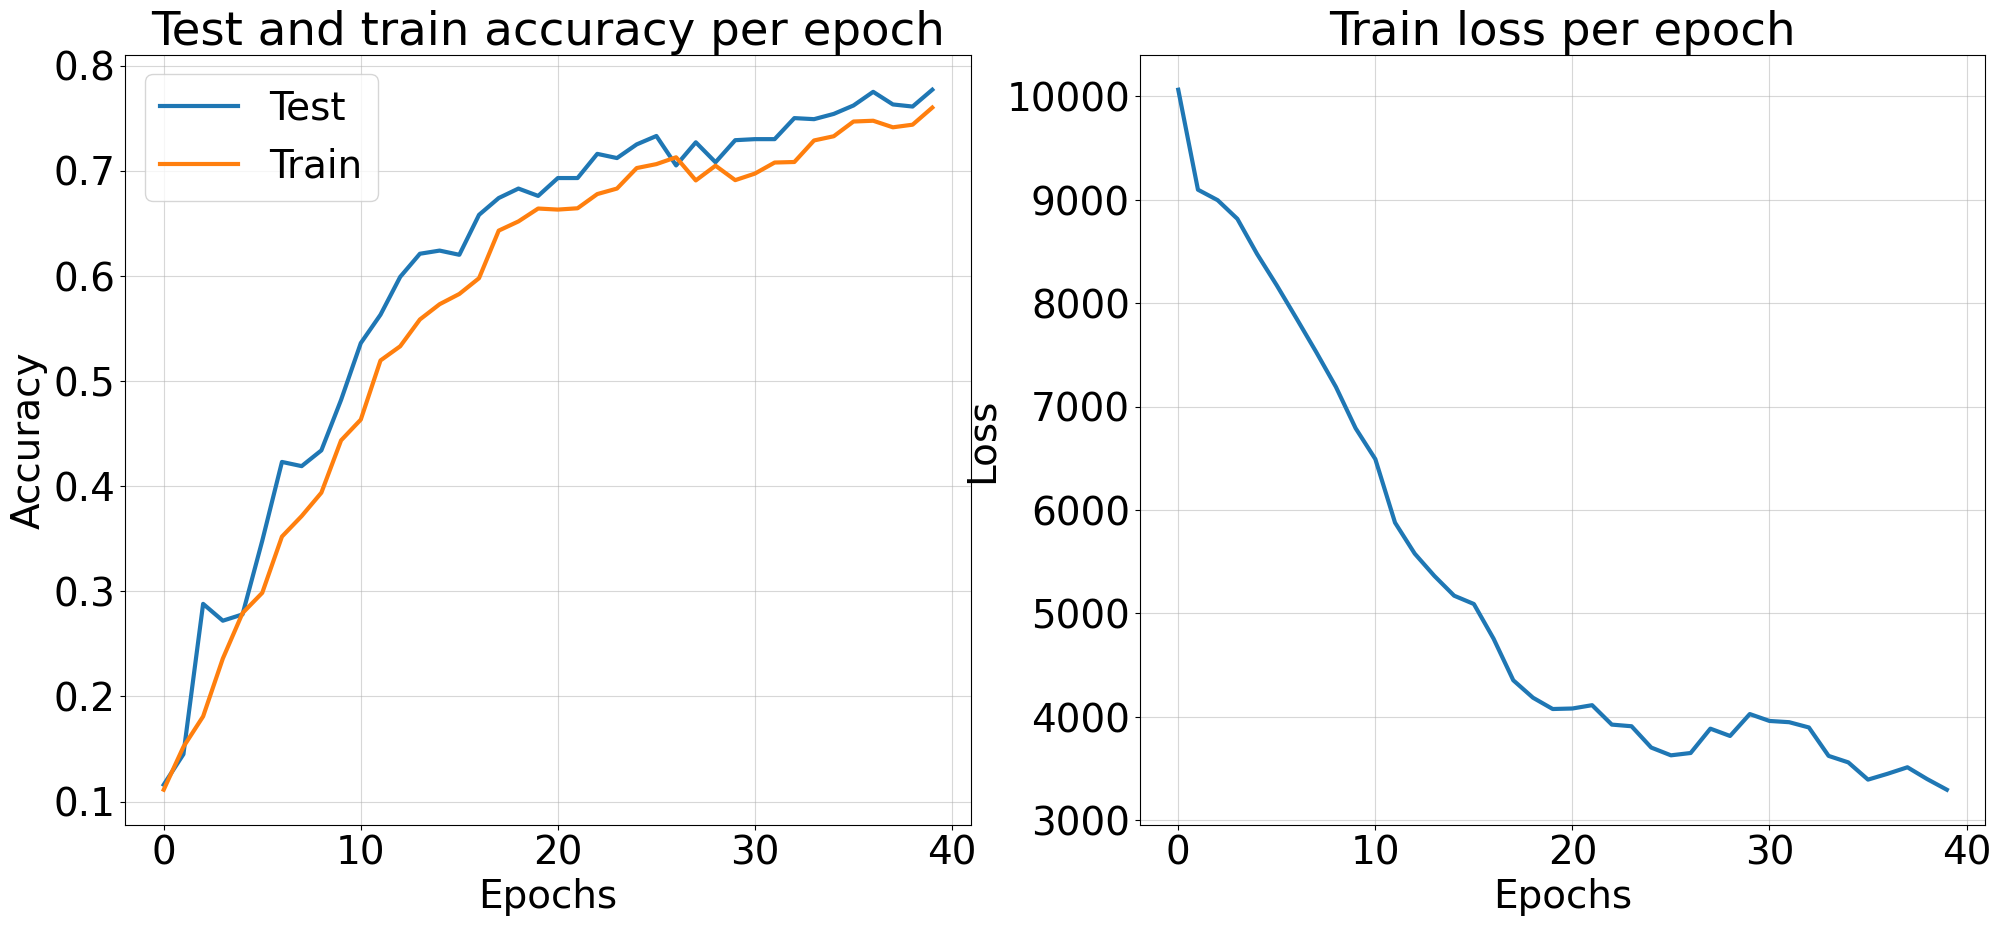

In [27]:
plt.figure(figsize=(24, 10))
plt.rcParams.update({'font.size': 28})


plt.subplot(1,2,1)
plt.plot(noisy_test_acc_per_epoch, linewidth=3, label='Test')
plt.plot(noisy_train_acc_per_epoch, linewidth=3, label='Train')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Test and train accuracy per epoch")
plt.grid(True, alpha=0.5)
plt.legend()


plt.subplot(1,2,2)
plt.plot(noisy_loss_per_epoch, linewidth=3)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train loss per epoch")
plt.grid(True, alpha=0.5)

plt.savefig('./subOSGM_acc_loss_eps10_delta1e-5_CNN.png')


'''
plt.plot(errors, linewidth=3)
plt.xlabel('Epoch')
plt.ylabel(r'cos($\hat{x}$, x)')
plt.title('Reconstruction Quality per Epoch')
plt.grid(True, alpha=0.7)
plt.savefig('./subOSGM_rec_error_eps10_delta1e-5_CNN.png')
'''

'''
plt.plot(avg_snr_per_epoch, linewidth=3)
plt.xlabel('Epoch')
plt.ylabel(r'Empirical SNR')
plt.title('Empirical SNR per epoch')
plt.grid(True, alpha=0.7)
plt.savefig('./subOSGM_emp_snr_per_epoch_eps10_delta1e-5_CNN.png')
'''

### One shot gaussian mechanism with subsampling.

<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_72180/4188055570.py:37: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(eps_arr, alpha_arr2[-1], linewidth=1.6, linestyle='-', label=rf'$\delta=10^{{{int(np.log10(delta))}}}$')


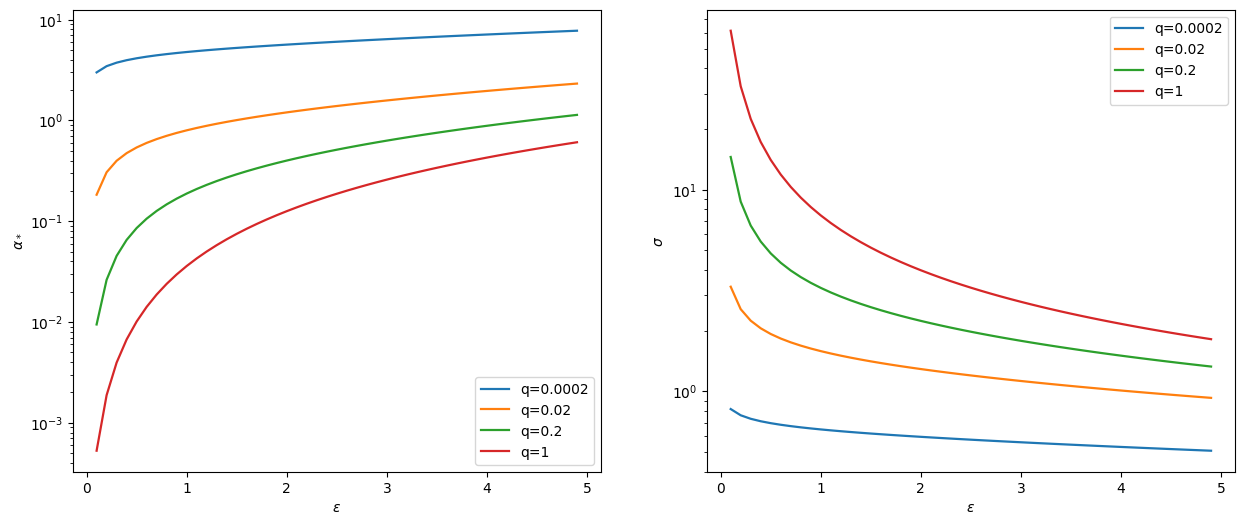

In [8]:
def delta_eps_alpha(eps, alpha, q):
    r_eps = math.log((math.exp(eps)-1+q)/q)
    term1 = (1-q-math.exp(eps)) * norm.cdf(-(r_eps + alpha)/math.sqrt(2*alpha))
    term2 = q * norm.cdf(-(r_eps - alpha)/math.sqrt(2*alpha))
    return term1 + term2

def find_alpha_star(eps, delta, q, lo=1e-8, hi=1e8, tol=1e-10):
    while hi - lo > tol:
        mid = (lo + hi)/2
        if delta_eps_alpha(eps, mid, q) > delta:
            hi = mid
        else:
            lo = mid
    return (lo + hi)/2

eps_arr = np.arange(0.1, 5, 0.1)
delta_arr = [1e-4, 1e-5, 1e-6]
delta_2 = 2 #L2 sensitivity
N = 400000 #number of elements in gradient.
B = 1
n_train = 5000
q = B/n_train

alpha_arr2 = []
sigma_arr2 = []
plt.figure(figsize=(15, 6))
'''
for delta in delta_arr:
    alpha_arr2.append([])
    sigma_arr2.append([])
    for eps in eps_arr:
        alpha_star = find_alpha_star(eps, delta, q)
        sigma = delta_2/(math.sqrt(2*alpha_star))
        alpha_arr2[-1].append(alpha_star)
        sigma_arr2[-1].append(sigma)
    plt.subplot(1,2,1)
    plt.plot(eps_arr, alpha_arr2[-1], linewidth=1.6, linestyle='-', label=rf'$\delta=10^{{{int(np.log10(delta))}}}$')
    plt.subplot(1,2,2)
    plt.plot(eps_arr, sigma_arr2[-1], linewidth=1.6, linestyle='-', label=rf'$\delta=10^{{{int(np.log10(delta))}}}$')
'''
delta = 1e-5
q_arr = [1/5000, 100/5000, 1000/5000, 1]
for q in q_arr:
    alpha_arr2.append([])
    sigma_arr2.append([])
    for eps in eps_arr:
        alpha_star = find_alpha_star(eps, delta, q)
        sigma = delta_2/(math.sqrt(2*alpha_star))
        alpha_arr2[-1].append(alpha_star)
        sigma_arr2[-1].append(sigma)
    plt.subplot(1,2,1)
    plt.semilogy(eps_arr, alpha_arr2[-1], linewidth=1.6, linestyle='-', label=rf'q={q}')
    plt.subplot(1,2,2)
    plt.semilogy(eps_arr, sigma_arr2[-1], linewidth=1.6, linestyle='-', label=rf'q={q}')

    
plt.subplot(1,2,1)
plt.locator_params(axis='x', nbins=10)
plt.xlabel(rf'$\epsilon$')
plt.ylabel(rf'$\alpha_*$')
plt.legend()
plt.subplot(1,2,2)
plt.locator_params(axis='x', nbins=10)
plt.xlabel(rf'$\epsilon$')
plt.ylabel(rf'$\sigma$')
plt.legend()
plt.show()
#plt.savefig('./subOSGM_params_epsilon_q.png')

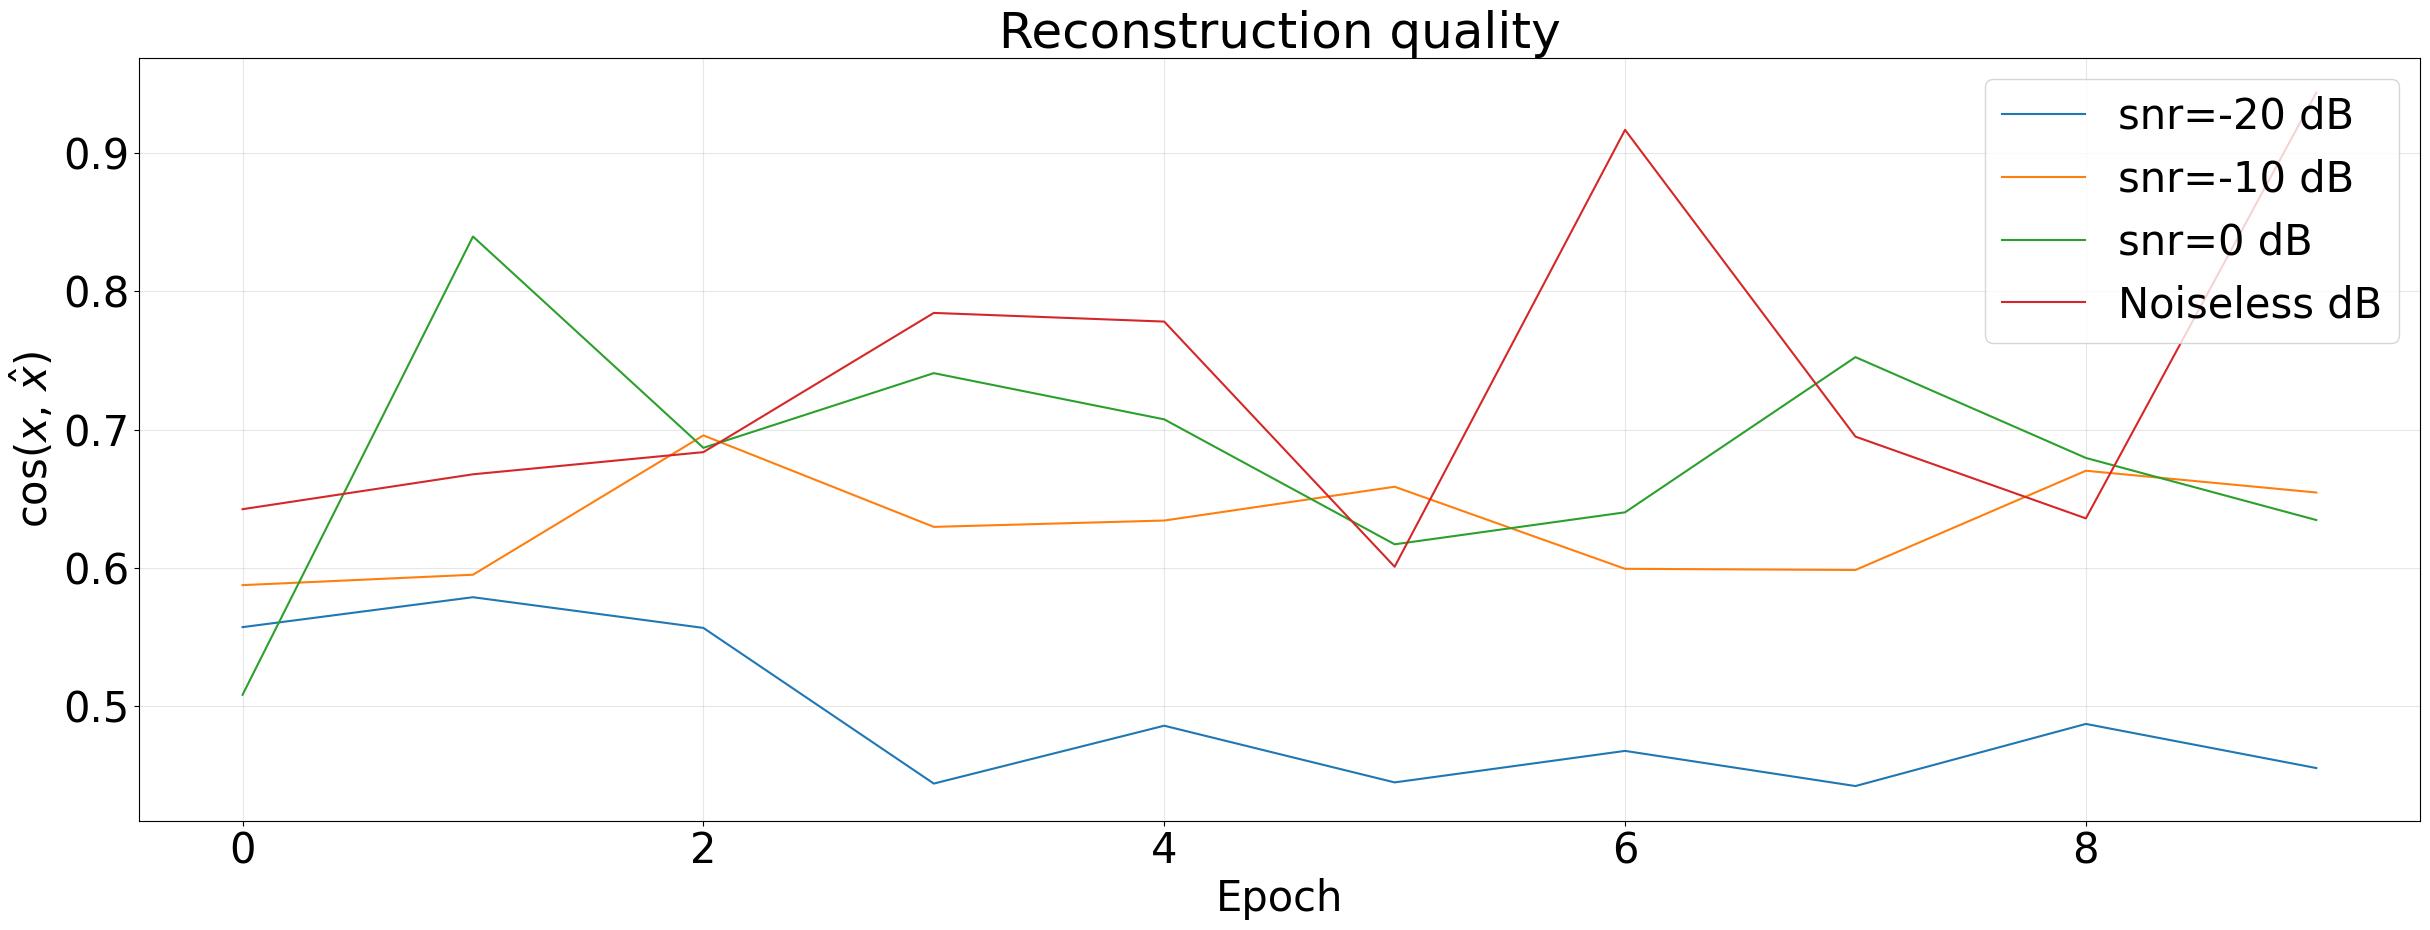

In [101]:
plt.figure(figsize=(25, 10))
plt.rcParams.update({'font.size': 30})

plt.plot(range(epochs), errors_snr['cosine similarity'][0], label=f'snr={int(10*np.log10(snr_arr[0]))} dB')
plt.plot(range(epochs), errors_snr['cosine similarity'][1], label=f'snr={int(10*np.log10(snr_arr[1]))} dB')
plt.plot(range(epochs), errors_snr['cosine similarity'][2], label=f'snr={int(10*np.log10(snr_arr[2]))} dB')
plt.plot(range(epochs), errors_snr['cosine similarity'][3], label=f'Noiseless dB')
#plt.plot(range(epochs), test_acc_per_epoch[0:epochs] , linestyle='-', linewidth=3, label='noisless')
plt.title('Reconstruction quality')
plt.xlabel('Epoch')
plt.ylabel(r'cos($x$, $\hat{x}$)')
plt.xticks(range(0, epochs, 2))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figure.png')